# Student Performance Analytics & Prediction

## Notebook 4: Model Evaluation

### Objective

Evaluate the performance of the Linear Regression model using regression metrics and visualizations

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [14]:
df = pd.read_csv("../data/student-por.csv")

x=df.drop("G3",axis=1)
y=df["G3"]

X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
categorical_cols=X_train.select_dtypes(include="object").columns.tolist()
numerical_cols=X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols),("num",StandardScaler(),numerical_cols)])
model=Pipeline([("preprocessor",preprocessor),("regressor",LinearRegression())])
model.fit(X_train, y_train)

C:\Users\Krish\AppData\Local\Temp\ipykernel_18972\1687468449.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=X_train.select_dtypes(include="object").columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['school','sex','age',...,'absences','G1','G2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with

In [51]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[18.40265613 11.82720849 18.56288575 10.80969554 11.74323992 16.52050538
 17.68642688  9.20547185 10.99263829 10.52990179]


In [54]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

MAE : 0.77
MSE : 1.48
RMSE: 1.21
R2 Score: 0.85


### Observation

- The model achieved an MAE of 0.77, meaning predictions are off by less than 1 mark on average
- he RMSE is 1.21, indicating that most prediction errors are around 1–1.5 marks
- The model achieved an R² Score of 0.85, meaning it explains about 85% of the variation in students' final grades

### Insight

- The Linear Regression model performs well on this dataset
- Prediction errors are relatively small, showing that the model generalizes well on unseen data
- An R² score of 0.85 indicates a strong relationship between the selected features and the final grade (G3)

### Possible Action

- Compare these results with Decision Tree and Random Forest models
- Choose the model with the highest R² score and the lowest prediction error
- Save the best-performing model for deployment

In [25]:
prediction_df=pd.DataFrame({"Actual":y_test.values,"Predicted":y_pred.round(2)})
prediction_df.head(10)

,Actual,Predicted
0,19,18.40
1,12,11.83
2,18,18.56
3,11,10.81
4,11,11.74
5,17,16.52
6,18,17.69
7,8,9.21
8,10,10.99
9,11,10.53


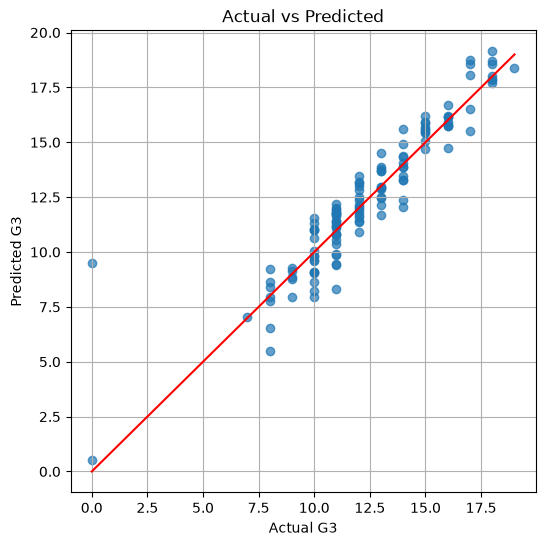

In [52]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()

### Observation

- Most predicted values are close to the actual values
- Some predictions are farther from the diagonal line
- Most predictions lie close to the diagonal line, indicating good prediction accuracy
### Insight

- Predictions near the diagonal indicate good model performance
- Larger deviations represent prediction errors

### Possible Action

- Improve the model by trying more advanced algorithms
- Compare this model with Decision Tree and Random Forest

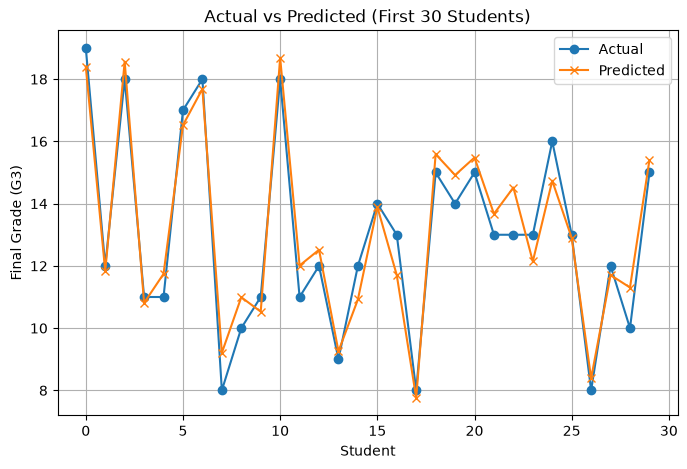

In [53]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:30], label="Actual", marker="o")
plt.plot(y_pred[:30], label="Predicted", marker="x")

plt.title("Actual vs Predicted (First 30 Students)")
plt.xlabel("Student")
plt.ylabel("Final Grade (G3)")

plt.legend()
plt.grid() 
plt.show()

## Final Conclusion

- Linear Regression successfully predicted students' final grades
- The model achieved an MAE of 0.77 and an RMSE of 1.21
- The R² score of 0.85 indicates that the model explains about 85% of the variation in the target variable
- This model will serve as the baseline for comparison with Decision Tree and Random Forest